# Time Series Analysis Foundations

## What is Time Series Data?

A **time series** is a sequence of data points indexed in time order. Unlike cross-sectional data, observations in a time series are **not independent** past values influence future ones.

**Examples:**
- Stock prices (daily close)
- Temperature readings (hourly)
- Monthly sales figures
- EEG brain signals (millisecond)
- GDP growth (quarterly)

Formally, a time series is a collection of random variables $\{Y_t\}$ indexed by time $t \in \mathcal{T}$, where $\mathcal{T}$ can be discrete or continuous.

## Components of a Time Series

Any time series can be decomposed into four components:

| Component | Symbol | Description |
|-----------|--------|-------------|
| **Trend** | $T_t$ | Long-term increase or decrease |
| **Seasonality** | $S_t$ | Regular, periodic fluctuations |
| **Cyclical** | $C_t$ | Irregular, multi-year fluctuations (business cycles) |
| **Irregular/Residual** | $R_t$ | Random noise |

### Additive Decomposition
Used when seasonal variation is **constant** over time:
$$Y_t = T_t + S_t + C_t + R_t$$

### Multiplicative Decomposition
Used when seasonal variation **grows** with the trend:
$$Y_t = T_t \times S_t \times C_t \times R_t$$

Can be linearised by taking logarithms:
$$\log Y_t = \log T_t + \log S_t + \log C_t + \log R_t$$

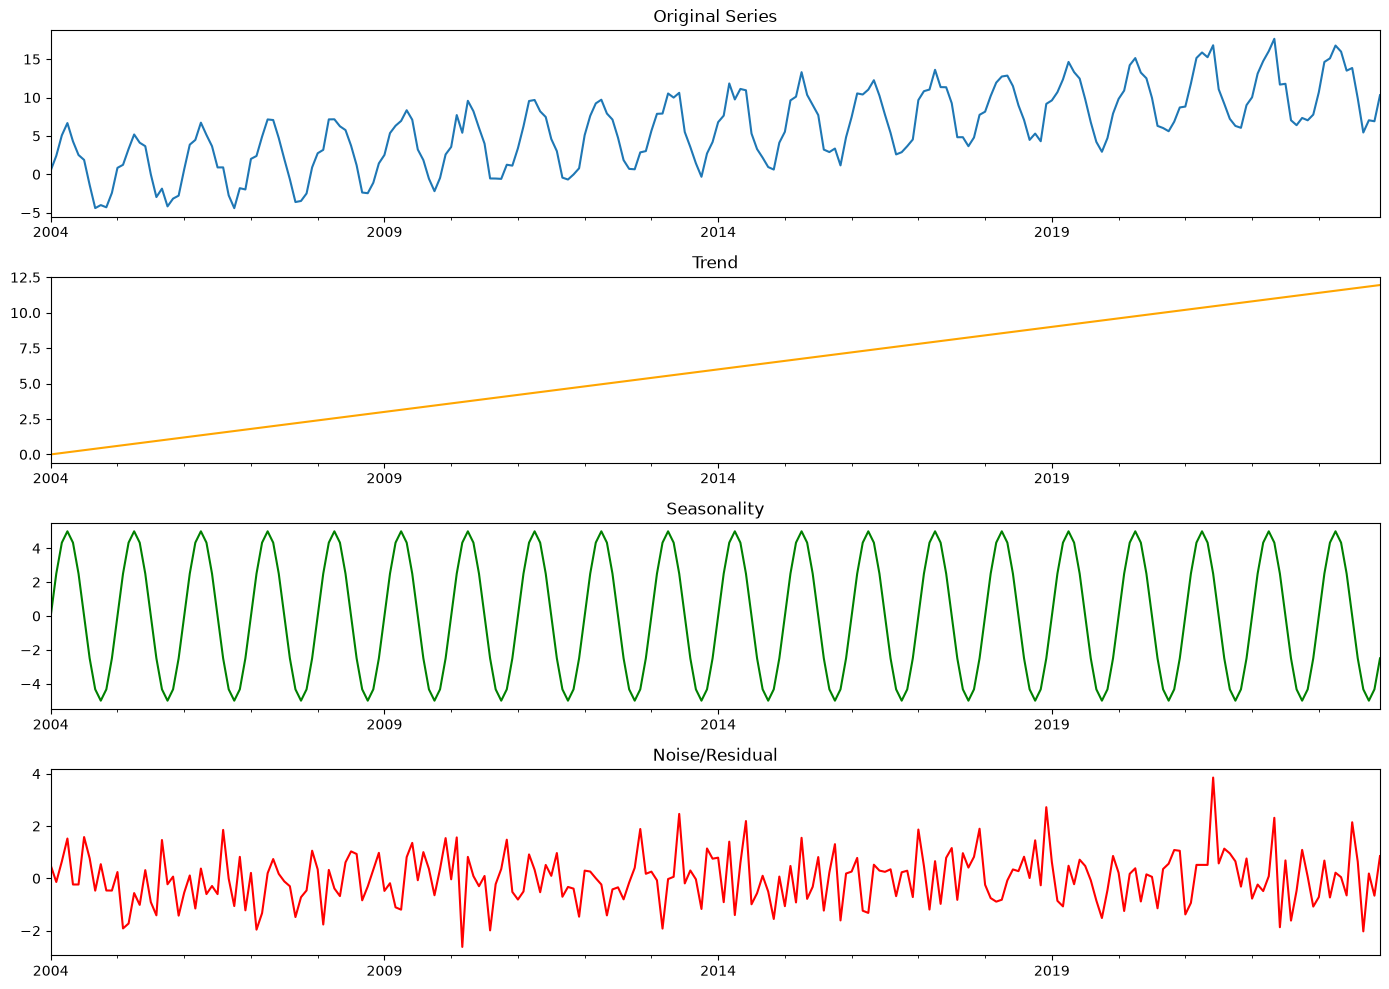

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Generate synthetic time series with trend + seasonality + noise
np.random.seed(42)
n = 240  # 20 years of monthly data
t = np.arange(n)

trend     = 0.05 * t                          # linear trend
seasonal  = 5 * np.sin(2 * np.pi * t / 12)   # annual seasonality
noise     = np.random.normal(0, 1, n)
ts        = trend + seasonal + noise

dates = pd.date_range(start='2004-01', periods=n, freq='MS')
series = pd.Series(ts, index=dates, name='value')

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
series.plot(ax=axes[0], title='Original Series')
pd.Series(trend, index=dates).plot(ax=axes[1], title='Trend', color='orange')
pd.Series(seasonal, index=dates).plot(ax=axes[2], title='Seasonality', color='green')
pd.Series(noise, index=dates).plot(ax=axes[3], title='Noise/Residual', color='red')
plt.tight_layout()
plt.show()

## Classical Decomposition with statsmodels

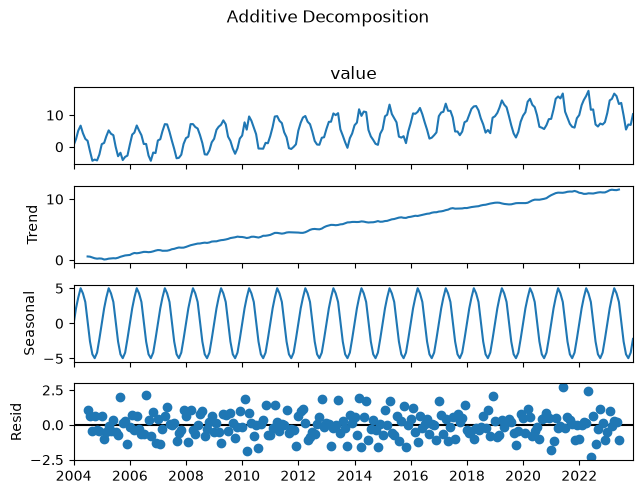

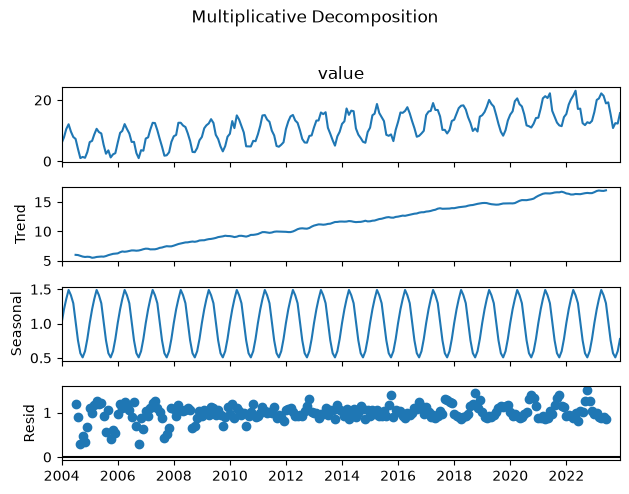

In [2]:
# Additive decomposition
result_add = seasonal_decompose(series, model='additive', period=12)
result_add.plot()
plt.suptitle('Additive Decomposition', y=1.02)
plt.tight_layout()
plt.show()

# Multiplicative decomposition (needs positive values)
series_pos = series - series.min() + 1
result_mul = seasonal_decompose(series_pos, model='multiplicative', period=12)
result_mul.plot()
plt.suptitle('Multiplicative Decomposition', y=1.02)
plt.tight_layout()
plt.show()

## Stationarity

A time series is **strictly stationary** if its joint probability distribution does not change over time.

More practically, a series is **weakly (covariance) stationary** if:
1. **Constant mean:** $\mathbb{E}[Y_t] = \mu$ for all $t$
2. **Constant variance:** $\text{Var}(Y_t) = \sigma^2 < \infty$ for all $t$
3. **Autocovariance depends only on lag:** $\text{Cov}(Y_t, Y_{t+k}) = \gamma(k)$ for all $t$

### Why Stationarity Matters
Most classical forecasting models (ARIMA, etc.) assume stationarity. A non-stationary series has unpredictable statistical properties, making forecasting unreliable.

### Making a Series Stationary
- **Differencing:** $Y'_t = Y_t - Y_{t-1}$ removes trends
- **Seasonal differencing:** $Y'_t = Y_t - Y_{t-m}$ removes seasonality
- **Log transformation:** stabilises variance
- **Detrending:** subtract fitted trend

## Augmented Dickey-Fuller (ADF) Test

The ADF test checks for a **unit root** (non-stationarity).

**Null hypothesis** $H_0$: The series has a unit root (non-stationary)
**Alternative** $H_1$: The series is stationary

The test regression:
$$\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \epsilon_t$$

Test statistic for $H_0: \gamma = 0$. If **p-value < 0.05**, reject $H_0$ → series is stationary.

## KPSS Test

**Null hypothesis** $H_0$: The series is stationary (opposite of ADF!)

Use both tests together:
| ADF | KPSS | Conclusion |
|-----|------|------------|
| Reject $H_0$ | Fail to reject $H_0$ | Stationary |
| Fail to reject $H_0$ | Reject $H_0$ | Non-stationary |
| Reject both | Reject both | Trend-stationary |

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(ts, name='Series'):
    print(f"=== Stationarity Tests for: {name} ===")
    
    # ADF Test
    adf_result = adfuller(ts.dropna())
    print(f"\nADF Test:")
    print(f"  Statistic : {adf_result[0]:.4f}")
    print(f"  p-value   : {adf_result[1]:.4f}")
    print(f"  Decision  : {'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")
    
    # KPSS Test
    kpss_result = kpss(ts.dropna(), regression='c')
    print(f"\nKPSS Test:")
    print(f"  Statistic : {kpss_result[0]:.4f}")
    print(f"  p-value   : {kpss_result[1]:.4f}")
    print(f"  Decision  : {'Non-Stationary' if kpss_result[1] < 0.05 else 'Stationary'}")
    print()

# Test original series (has trend non-stationary)
test_stationarity(series, 'Original')

# First difference
diff1 = series.diff()
test_stationarity(diff1, 'First Difference')

=== Stationarity Tests for: Original ===

ADF Test:
  Statistic : 0.0451
  p-value   : 0.9621
  Decision  : Non-Stationary

KPSS Test:
  Statistic : 2.3120
  p-value   : 0.0100
  Decision  : Non-Stationary

=== Stationarity Tests for: First Difference ===

ADF Test:
  Statistic : -12.0459
  p-value   : 0.0000
  Decision  : Stationary

KPSS Test:
  Statistic : 0.0087
  p-value   : 0.1000
  Decision  : Stationary



/tmp/ipykernel_38331/4071794402.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c')
/tmp/ipykernel_38331/4071794402.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c')


## Autocorrelation (ACF)

The **Autocorrelation Function** measures the correlation between a series and its lagged version.

$$\rho(k) = \frac{\text{Cov}(Y_t, Y_{t-k})}{\text{Var}(Y_t)} = \frac{\gamma(k)}{\gamma(0)}$$

where:
$$\gamma(k) = \frac{1}{n} \sum_{t=k+1}^{n} (Y_t - \bar{Y})(Y_{t-k} - \bar{Y})$$

ACF values range from $-1$ to $1$. Confidence bands are typically $\pm \frac{1.96}{\sqrt{n}}$.

## Partial Autocorrelation (PACF)

The **PACF** at lag $k$ is the correlation between $Y_t$ and $Y_{t-k}$ after removing the effect of all intermediate lags $Y_{t-1}, \ldots, Y_{t-k+1}$.

Computed via the **Yule-Walker equations** or OLS regression:
$$Y_t = \phi_{k,1} Y_{t-1} + \phi_{k,2} Y_{t-2} + \ldots + \phi_{k,k} Y_{t-k} + \epsilon_t$$

The PACF at lag $k$ is $\phi_{k,k}$.

### Interpreting ACF and PACF for Model Selection

| Pattern | AR(p) | MA(q) | ARMA |
|---------|-------|-------|------|
| ACF | Tails off | Cuts off after lag q | Tails off |
| PACF | Cuts off after lag p | Tails off | Tails off |

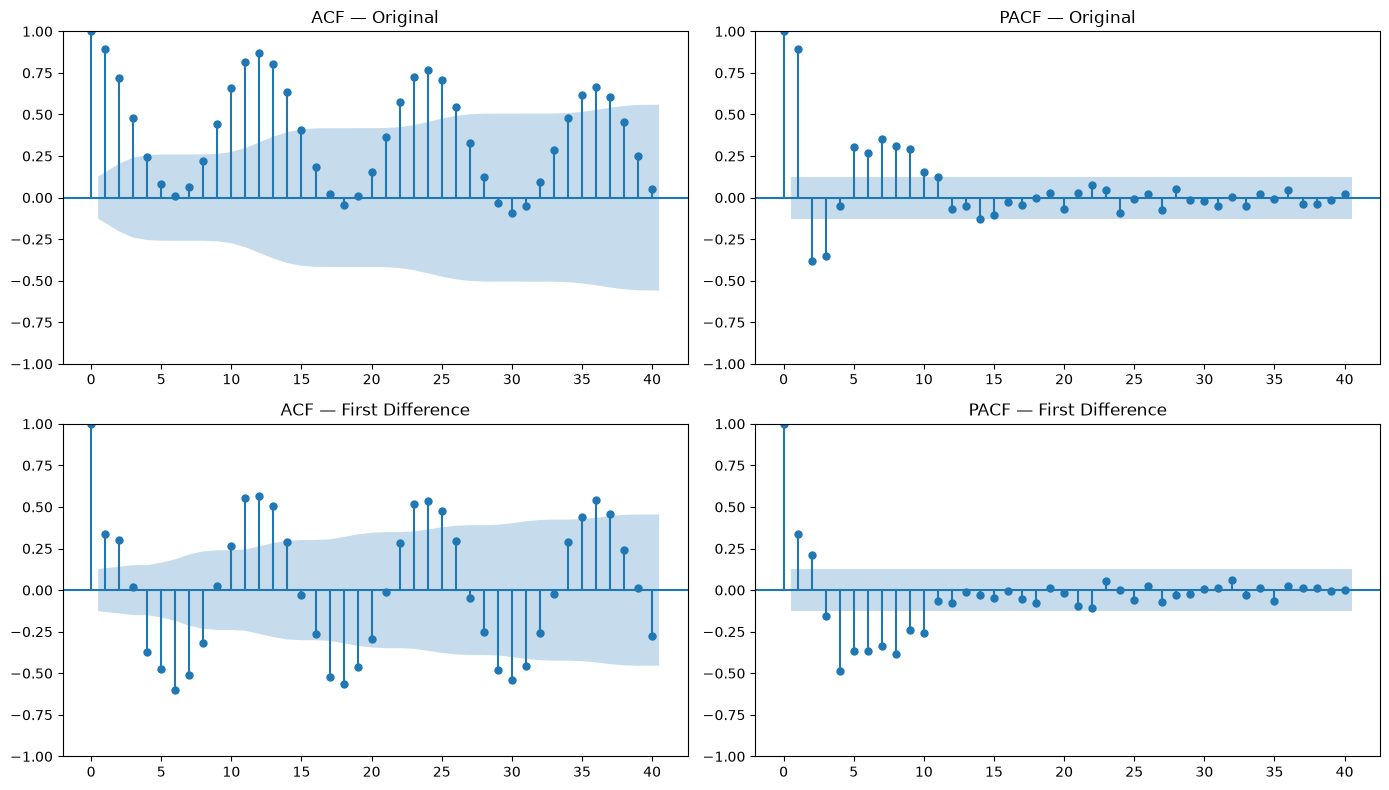

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(series, lags=40, ax=axes[0,0], title='ACF Original')
plot_pacf(series, lags=40, ax=axes[0,1], title='PACF Original')
plot_acf(diff1.dropna(), lags=40, ax=axes[1,0], title='ACF First Difference')
plot_pacf(diff1.dropna(), lags=40, ax=axes[1,1], title='PACF First Difference')

plt.tight_layout()
plt.show()

## Rolling Statistics

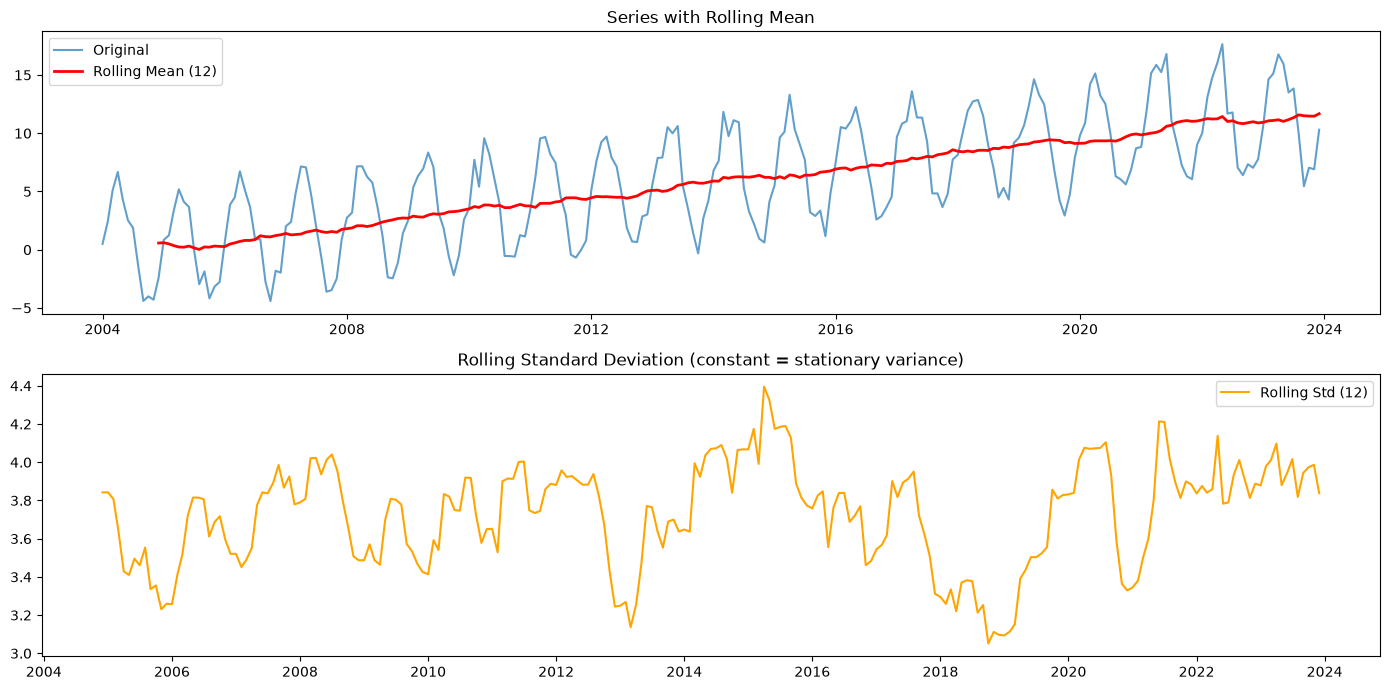

In [5]:
window = 12
rolling_mean = series.rolling(window=window).mean()
rolling_std  = series.rolling(window=window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(series, label='Original', alpha=0.7)
axes[0].plot(rolling_mean, label=f'Rolling Mean ({window})', color='red', linewidth=2)
axes[0].set_title('Series with Rolling Mean')
axes[0].legend()

axes[1].plot(rolling_std, label=f'Rolling Std ({window})', color='orange')
axes[1].set_title('Rolling Standard Deviation (constant = stationary variance)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Lag Plots

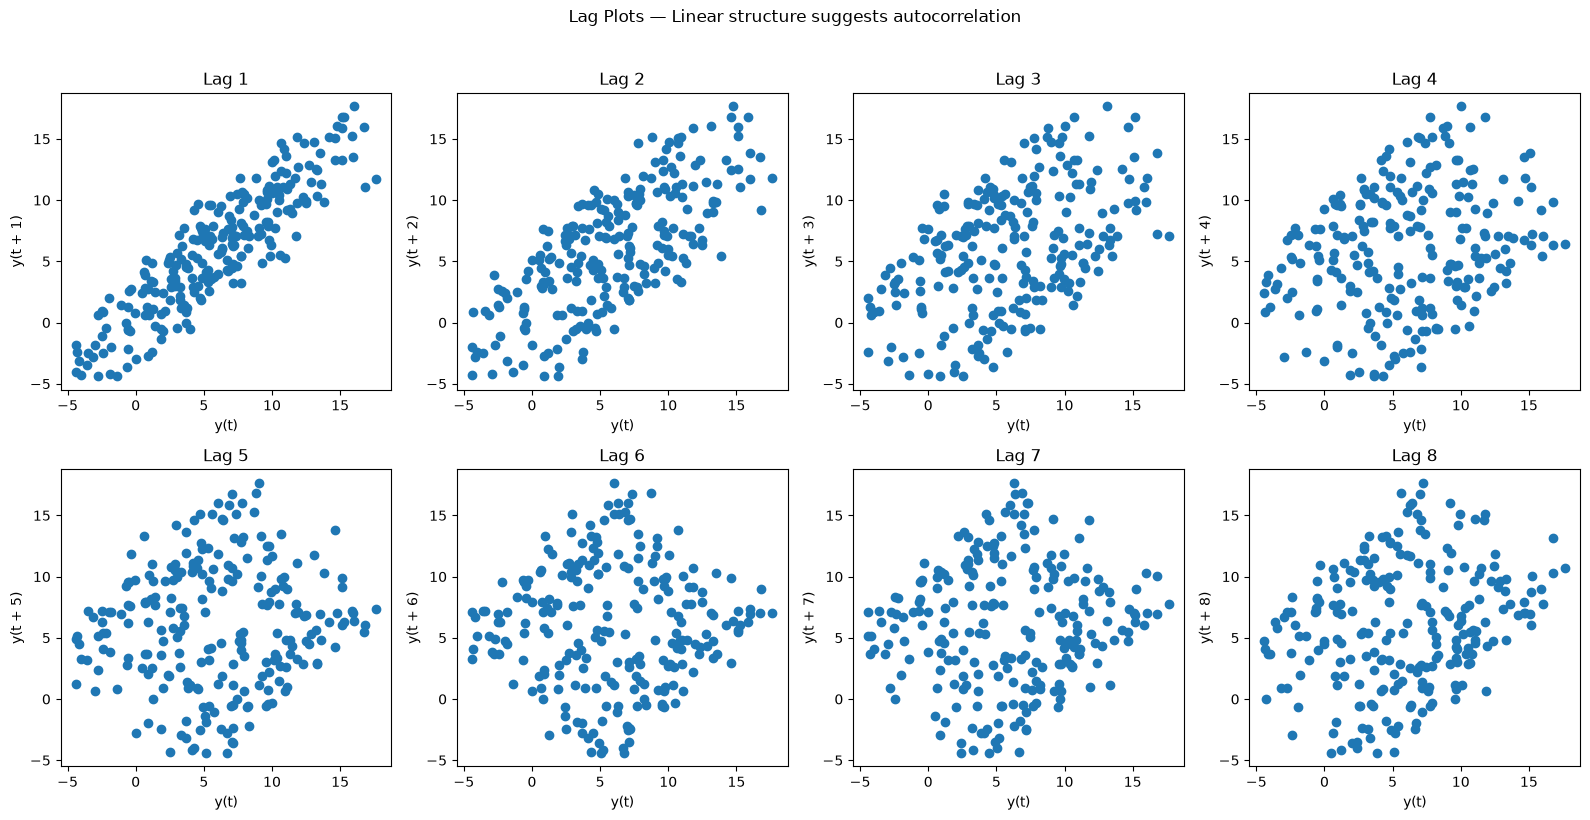

In [6]:
from pandas.plotting import lag_plot

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat, start=1):
    lag_plot(series, lag=i, ax=ax)
    ax.set_title(f'Lag {i}')
plt.suptitle('Lag Plots Linear structure suggests autocorrelation', y=1.02)
plt.tight_layout()
plt.show()

## Differencing

**First-order differencing** removes a linear trend:
$$\nabla Y_t = Y_t - Y_{t-1} = (1 - B) Y_t$$

where $B$ is the **backshift operator**: $BY_t = Y_{t-1}$.

**Second-order differencing** removes a quadratic trend:
$$\nabla^2 Y_t = \nabla(\nabla Y_t) = Y_t - 2Y_{t-1} + Y_{t-2}$$

**Seasonal differencing** at period $m$:
$$\nabla_m Y_t = Y_t - Y_{t-m} = (1 - B^m) Y_t$$

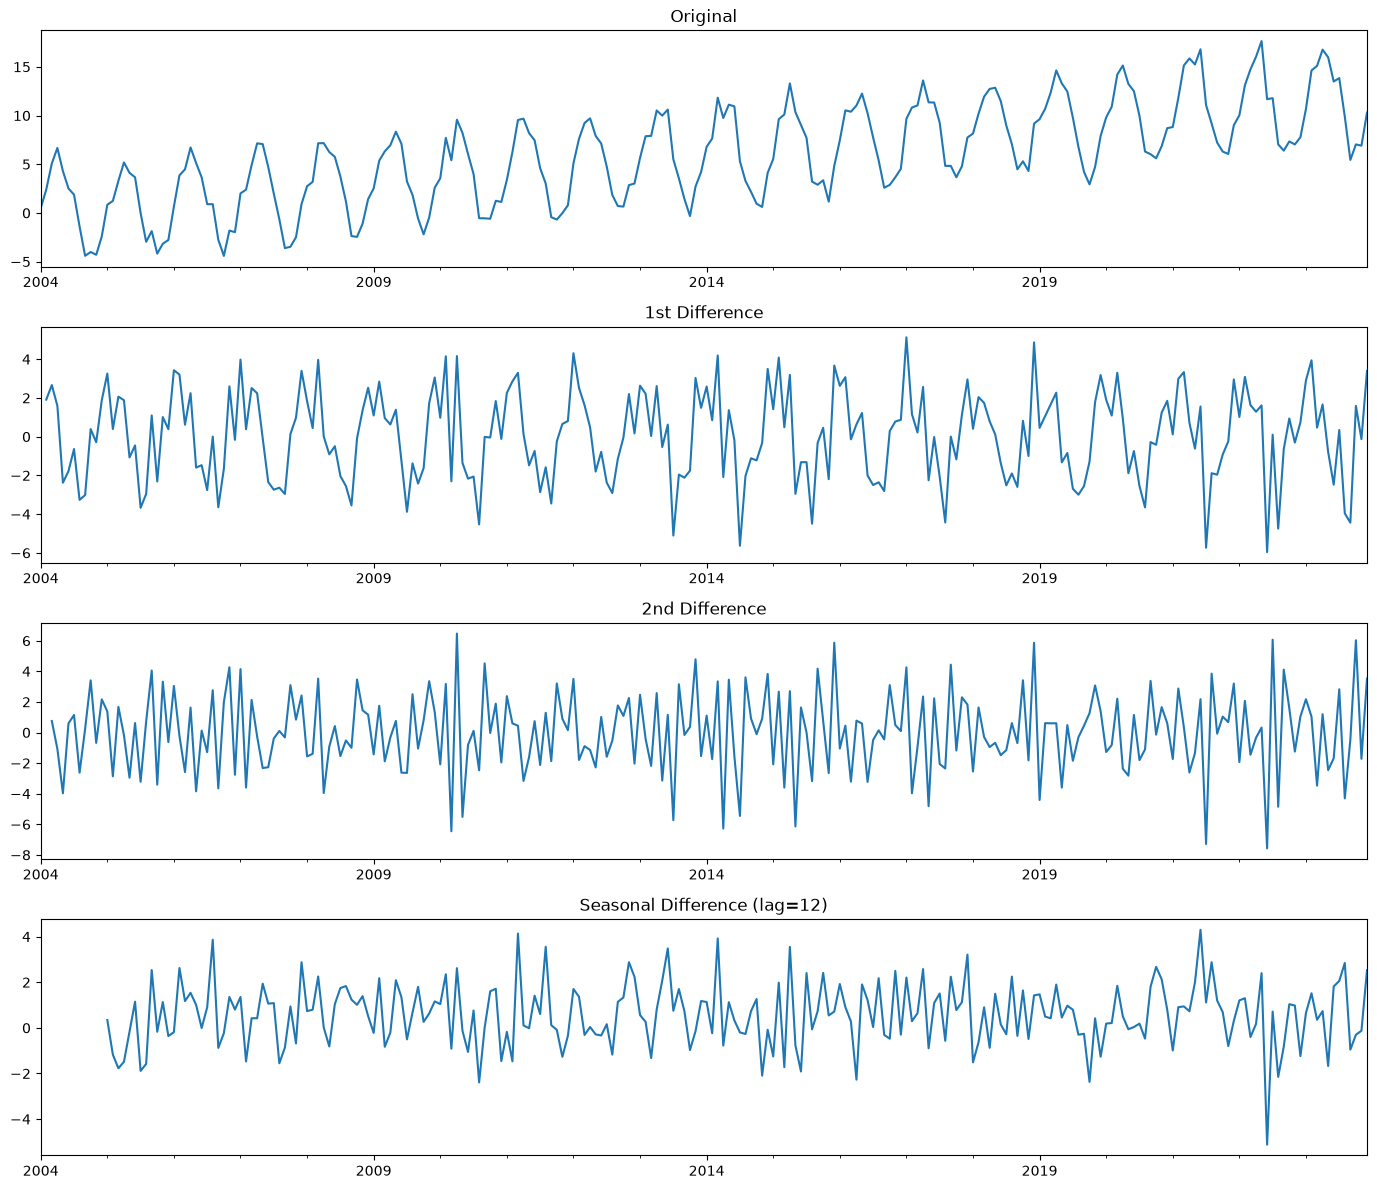

ADF on seasonal difference:
=== Stationarity Tests for: Seasonal Diff ===

ADF Test:
  Statistic : -6.5965
  p-value   : 0.0000
  Decision  : Stationary

KPSS Test:
  Statistic : 0.0453
  p-value   : 0.1000
  Decision  : Stationary



/tmp/ipykernel_38331/4071794402.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c')


In [7]:
diff1_series  = series.diff(1)           # first difference
diff2_series  = series.diff(1).diff(1)   # second difference
diff12_series = series.diff(12)          # seasonal difference (monthly data)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
series.plot(ax=axes[0], title='Original')
diff1_series.plot(ax=axes[1], title='1st Difference')
diff2_series.plot(ax=axes[2], title='2nd Difference')
diff12_series.plot(ax=axes[3], title='Seasonal Difference (lag=12)')
plt.tight_layout()
plt.show()

print('ADF on seasonal difference:')
test_stationarity(diff12_series, 'Seasonal Diff')

## STL Decomposition (Seasonal and Trend using LOESS)

STL is a more robust decomposition method that can handle changing seasonality and is resistant to outliers.

Uses **LOESS** (Locally Estimated Scatterplot Smoothing) for both trend and seasonal components.

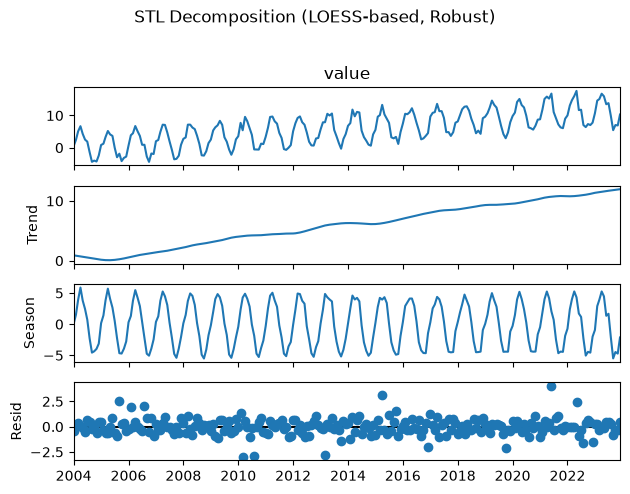

Trend strength:    0.950
Seasonal strength: 0.948


In [8]:
from statsmodels.tsa.seasonal import STL

stl = STL(series, period=12, robust=True)
stl_result = stl.fit()
stl_result.plot()
plt.suptitle('STL Decomposition (LOESS-based, Robust)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Trend strength:    {max(0, 1 - stl_result.resid.var() / (stl_result.resid + stl_result.trend).var()):.3f}")
print(f"Seasonal strength: {max(0, 1 - stl_result.resid.var() / (stl_result.resid + stl_result.seasonal).var()):.3f}")

## White Noise Test

A series is **white noise** if:
$$\mathbb{E}[\epsilon_t] = 0, \quad \text{Var}(\epsilon_t) = \sigma^2, \quad \text{Cov}(\epsilon_t, \epsilon_s) = 0 \; \forall t \neq s$$

**Ljung-Box test** checks whether any of the first $h$ autocorrelations differ from zero:
$$Q(h) = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k} \sim \chi^2_h$$

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = stl_result.resid
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test on STL Residuals:")
print(lb_test)
print("\nIf p-value > 0.05: residuals look like white noise (good decomposition)")

Ljung-Box Test on STL Residuals:
      lb_stat  lb_pvalue
10  13.083648   0.219032
20  41.082167   0.003636
30  46.350886   0.028761

If p-value > 0.05: residuals look like white noise (good decomposition)


## Summary: Time Series Analysis Checklist

```
1. Plot the series identify obvious trend, seasonality, outliers
2. Decompose additive or multiplicative?
3. Test stationarity ADF + KPSS
4. Transform if needed log, differencing
5. Plot ACF/PACF identify AR/MA orders
6. Check for seasonality period ACF peaks, domain knowledge
7. Check residuals Ljung-Box test for white noise
```

---

## Additional Learning Resources

### Books
- **Forecasting: Principles and Practice (3rd ed.)** Rob Hyndman & George Athanasopoulos. Free online: https://otexts.com/fpp3/
- **Time Series Analysis** James D. Hamilton (graduate-level rigour)
- **Introduction to Time Series and Forecasting** Brockwell & Davis

### Courses
- Coursera: Sequences, Time Series and Prediction https://www.coursera.org/learn/tensorflow-sequences-time-series-and-prediction
- Kaggle Time Series Course https://www.kaggle.com/learn/time-series

### Papers
- Cleveland et al. (1990) STL: A Seasonal-Trend Decomposition https://www.scb.se/contentassets/ca21efb41fee47d293bbee5bf7be7fb3/stl-a-seasonal-trend-decomposition-procedure-based-on-loess.pdf
- Hyndman & Athanasopoulos (2018) Forecasting: Principles and Practice

### Python Libraries
- statsmodels: https://www.statsmodels.org/stable/tsa.html
- pandas time series: https://pandas.pydata.org/docs/user_guide/timeseries.html
- sktime: https://www.sktime.net/en/stable/

### Videos
- StatQuest Time Series Playlist https://www.youtube.com/playlist?list=PLblh5JKOoLUJo2Q6xK4tZElbIvAACEykp
- 3Blue1Brown Fourier series (for understanding seasonality) https://www.youtube.com/watch?v=spUNpyF58BY